In [1]:
import pickle as pkl
import numpy as np
import matplotlib.pylab as plt

In [52]:
latency = None
c = 299792458
with open("./bw.pkl", "rb") as f:
    bw = pkl.load(f)

In [58]:
bw = np.array(bw)

In [60]:
# plt.hist(bw[0] >= 8)

print(np.sum(bw[0] >= 50))

4


In [40]:
with open("./latency_latest.pkl", "rb") as f:
    latency = pkl.load(f)

In [43]:
latency[0]

[0.0,
 3.640204769219234,
 11.442529546008457,
 18.964564688136875,
 25.898708923929515,
 41.19506776155857,
 43.99671469832497,
 45.4374254406674,
 44.201611347077616,
 41.57872460837412,
 32.544100050731565,
 26.546575415343014,
 16.65373752018732,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,

In [4]:
latency = np.array(latency)

In [61]:
with open("./distance.pkl", "rb") as f:
    distance = pkl.load(f)

latency_org = distance / c * 1000

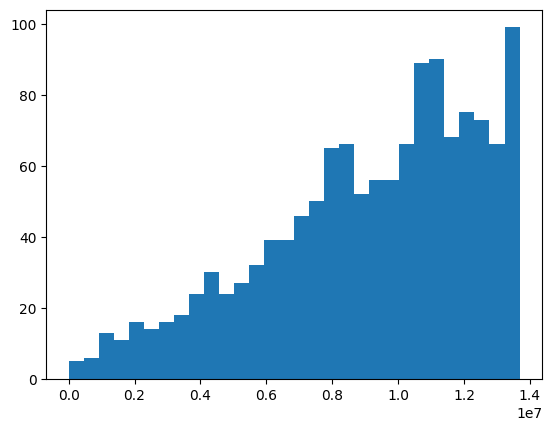

In [72]:
plt.hist(distance[0, :], 30);

Fitting 106 distributions:  24%|██▎       | 25/106 [00:05<00:24,  3.35it/s]/home/farzad/miniconda3/envs/py37/lib/python3.7/site-packages/scipy/stats/_continuous_distns.py:3094: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  t1 = integrate.quad(llc, -np.inf, x)[0]
Fitting 106 distributions:  82%|████████▏ | 87/106 [01:16<00:46,  2.43s/it]/home/farzad/miniconda3/envs/py37/lib/python3.7/site-packages/scipy/integrate/quadpack.py:880: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  **opt)
Fitting 106 distributions:  85%|████████▍ | 90/106 [01:23<00:36,  2

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
powerlaw,4.952057e-14,3344.905360,-50330.247617,inf,0.025663,0.338893
trapezoid,4.962857e-14,3352.602511,-50320.154343,inf,0.024116,0.414696
trapz,4.962857e-14,3352.602511,-50320.154343,inf,0.024116,0.414696
gausshyper,5.003344e-14,3350.497822,-50294.952498,inf,0.030038,0.177374
beta,5.010182e-14,3345.463296,-50307.522051,inf,0.029899,0.181340


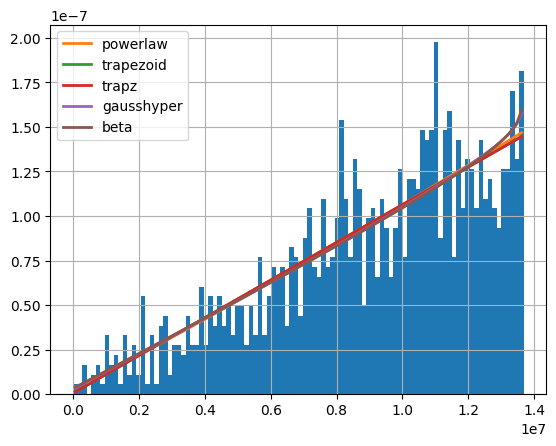

/home/farzad/miniconda3/envs/py37/lib/python3.7/site-packages/scipy/stats/_continuous_distns.py:4837: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  intg = integrate.quad(f, -xi, np.pi/2, **intg_kwargs)[0]


In [73]:
from fitter import Fitter

f = Fitter(distance[0, :])
f.fit()
f.summary()

In [79]:
f.get_best()

{'powerlaw': {'a': 2.0806719894902956,
  'loc': -411295.73644980986,
  'scale': 14097076.288494637}}

In [ ]:
import scipy

In [90]:
shape, loc, scale = scipy.stats.gamma.fit(distance[0, :])

In [92]:
r = scipy.stats.powerlaw.rvs(2.0806719894902956, loc = -411295.73644980986, scale = 14097076.288494637, size = (100, 100))
r_gamma = np.random.gamma(shape=shape, scale = scale, size = (100, 100))

In [97]:

r = r + np.abs(np.min(r.ravel()))

In [100]:
with open("distance_gen.pkl", "wb") as f:
    pkl.dump(r, f)

(array([  98.,  276.,  485.,  676.,  848., 1116., 1297., 1503., 1730.,
        1971.]),
 array([       0.        ,  1390647.51408523,  2781295.02817047,
         4171942.5422557 ,  5562590.05634093,  6953237.57042617,
         8343885.0845114 ,  9734532.59859663, 11125180.11268187,
        12515827.6267671 , 13906475.14085233]),
 <BarContainer object of 10 artists>)

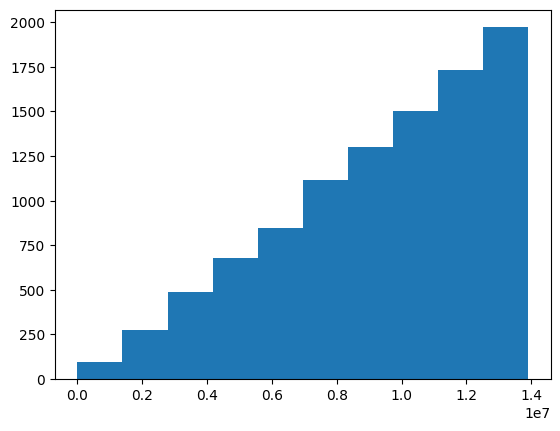

In [99]:
plt.hist(r.ravel())

In [8]:
print(latency_org.shape)
print(latency.shape)

(1331, 1331)
(1337, 1337)


In [36]:
print(np.sum(latency == 0))

1770266


In [9]:
latency_new = latency[0:1331, 0:1331]

(array([1.754323e+06, 1.820000e+02, 2.330000e+02, 3.340000e+02,
        3.800000e+02, 4.550000e+02, 5.470000e+02, 5.720000e+02,
        6.920000e+02, 7.520000e+02, 8.690000e+02, 9.750000e+02,
        1.141000e+03, 1.281000e+03, 1.368000e+03, 1.492000e+03,
        1.389000e+03, 1.375000e+03, 1.476000e+03, 1.725000e+03]),
 array([ 0.        ,  2.31064656,  4.62129312,  6.93193968,  9.24258624,
        11.55323281, 13.86387937, 16.17452593, 18.48517249, 20.79581905,
        23.10646561, 25.41711217, 27.72775873, 30.03840529, 32.34905186,
        34.65969842, 36.97034498, 39.28099154, 41.5916381 , 43.90228466,
        46.21293122]),
 <BarContainer object of 20 artists>)

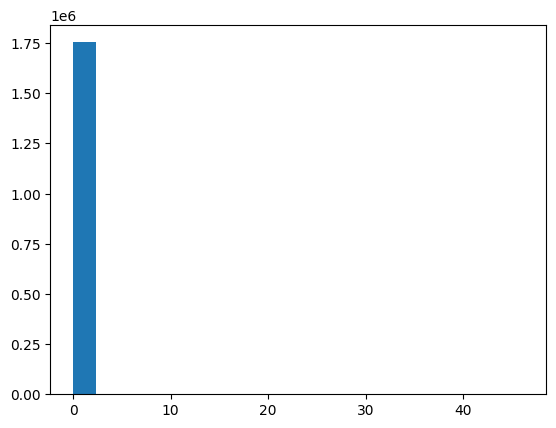

In [15]:
plt.hist(latency_new.ravel())

In [47]:
len(latency_new.ravel()[latency_new.ravel() > 20])

14090

In [17]:
old = np.array(latency_org).ravel()
new = latency_new.ravel()

In [27]:
print(len(old))

1771561


In [30]:
np.where(old != new)

(array([     13,      14,      15, ..., 1771557, 1771558, 1771559]),)

In [33]:
print(old[0:20])
print(new[0:20])

[ 0.          3.64020477 11.44252955 18.96456469 25.89870892 41.19506776
 43.9967147  45.43742544 44.20161135 41.57872461 32.54410005 26.54657542
 16.65373752 12.22236351  4.4014882  36.63172897 40.79642759 43.7159498
 45.33871492 45.57681635]
[ 0.          3.64020477 11.44252955 18.96456469 25.89870892 41.19506776
 43.9967147  45.43742544 44.20161135 41.57872461 32.54410005 26.54657542
 16.65373752  0.          0.          0.          0.          0.
  0.          0.        ]


In [101]:
with open("phi_i_j_0", "rb") as f:

    phi_ = pkl.load(f)

In [107]:
with open("distance_gen.pkl", "rb") as f:

    gen_dist = pkl.load(f)

In [111]:
from scipy.io import savemat

In [112]:
savemat("gen.mat", {"data":gen_dist})

In [113]:
savemat("phi.mat", {"phi":phi_})